In [1]:
pip install -e .

Obtaining file:///C:/Users/Vaibhav%20Patil/Desktop/PyML
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for pyml (pyproject.toml): started
  Building editable for pyml (pyproject.toml): finished with status 'done'
  Created wheel for pyml: filename=pyml-0.1.0-0.editable-py3-none-any.whl size=4520 sha256=4fb15519cc45a1b830dca5e615834be5debb6554e3aad3418b4562fdfae3e733
  Stored in directory: C:\Users\Vaibhav Patil\AppData\Local\Temp\pip-ephem-wheel-cache-o9x2famr\wheels\cc\5b\a3\78b8f9d3517b281140892b88d8a60cf37a5f1970b87581edec

In [2]:
import pyml

In [3]:
import nltk

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Vaibhav
[nltk_data]     Patil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Vaibhav
[nltk_data]     Patil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
from pyml.intelligence.auto_selector import AutoModelSelector
from pyml.intelligence.explainability import ModelExplainer

In [6]:
import pandas as pd

import numpy as np

from pyml.model.model_engine import ModelEngine
from pyml.core.base import BaseModule

print("pymll imported succesfully")

pymll imported succesfully


In [7]:
# ===============================
# PyML Full System Test - Cell 2
# ===============================

from sklearn.datasets import make_classification

# Create dataset
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(10)])
df["target"] = y

# Add artificial missing values
df.loc[df.sample(frac=0.05, random_state=42).index, "feature_0"] = np.nan
df.loc[df.sample(frac=0.03, random_state=1).index, "feature_3"] = np.nan

print("Dataset Created Successfully ✅")
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Created Successfully ✅

Shape: (500, 11)

Missing Values:
 feature_0    25
feature_1     0
feature_2     0
feature_3    15
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
target        0
dtype: int64


In [8]:
# ===============================
# PyML Full System Test - Cell 3
# ===============================

base = BaseModule()

# Validate dataset
base.validate_data(df)

# Check shape
shape = base.check_shape(df)

# Missing summary
missing_summary = base.get_missing_summary(df)

print("Data Validation Successful ✅")
print("\nDataset Shape:", shape)
print("\nMissing Summary:\n")
print(missing_summary)

2026-02-28 14:11:11,432 - INFO - BaseModule initialized


Data Validation Successful ✅

Dataset Shape: (500, 11)

Missing Summary:

feature_0    25
feature_1     0
feature_2     0
feature_3    15
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
target        0
dtype: int64


In [9]:
# ===============================
# PyML Full System Test - Cell 4
# ===============================

from sklearn.model_selection import train_test_split

# Fill missing values (numerical mean)
df_filled = df.fillna(df.mean(numeric_only=True))

# Separate features & target
X = df_filled.drop("target", axis=1)
y = df_filled["target"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=base.config.TEST_SIZE,
    random_state=base.config.RANDOM_STATE
)

print("Missing Values Handled ✅")
print("Train/Test Split Done ✅")

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Missing Values Handled ✅
Train/Test Split Done ✅

X_train shape: (400, 10)
X_test shape: (100, 10)


In [10]:
# ===============================
# PyML Full System Test - Cell 5
# ===============================

from pyml.model.model_engine import ModelEngine

engine = ModelEngine()

# Auto model selection
model = engine.train(
    X_train,
    y_train,
    model_name="auto"
)

print("Model trained using PyML AUTO mode ✅")
print("Selected Model:", type(model).__name__)

2026-02-28 14:11:11,849 - INFO - BaseModule initialized
2026-02-28 14:11:11,853 - INFO - ModelEngine initialized
2026-02-28 14:11:14,736 - INFO - random_forest_classifier trained successfully


Model trained using PyML AUTO mode ✅
Selected Model: RandomForestClassifier


In [11]:
# ===============================
# PyML Full System Test - Cell 6
# ===============================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Prediction Done ✅")
print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Prediction Done ✅

Accuracy: 89.0 %

Classification Report:

              precision    recall  f1-score   support

           0       0.77      1.00      0.87        37
           1       1.00      0.83      0.90        63

    accuracy                           0.89       100
   macro avg       0.89      0.91      0.89       100
weighted avg       0.92      0.89      0.89       100


Confusion Matrix:

[[37  0]
 [11 52]]


Feature Importance ✅

     Feature  Importance
0  feature_0    0.242478
4  feature_4    0.163993
7  feature_7    0.102775
8  feature_8    0.099465
5  feature_5    0.091481
3  feature_3    0.082326
9  feature_9    0.078071
1  feature_1    0.065820
2  feature_2    0.038566
6  feature_6    0.035025


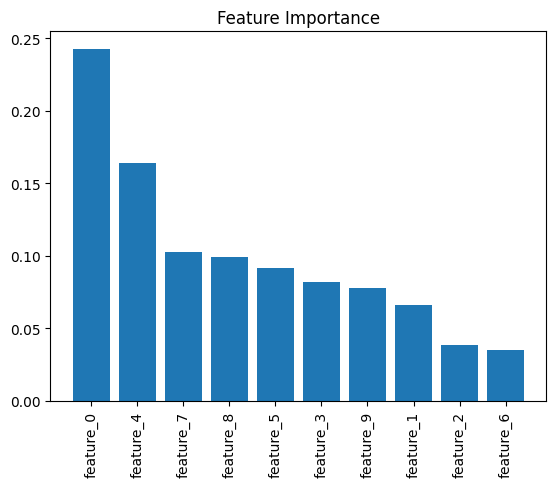

In [12]:
# ===============================
# PyML Full System Test - Cell 7
# ===============================

import matplotlib.pyplot as plt
import pandas as pd

# Check if model has feature_importances_
if hasattr(model, "feature_importances_"):

    importances = model.feature_importances_
    feature_names = X_train.columns

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("Feature Importance ✅\n")
    print(importance_df)

    # Plot
    plt.figure()
    plt.bar(importance_df["Feature"], importance_df["Importance"])
    plt.xticks(rotation=90)
    plt.title("Feature Importance")
    plt.show()

else:
    print("This model does not support feature importance.")

In [13]:
# ===============================
# PyML Full Workflow - Cell 1
# ===============================

import pandas as pd
import numpy as np

# Create synthetic dataset
np.random.seed(42)

data = pd.DataFrame({
    "age": np.random.randint(18, 60, 200),
    "salary": np.random.randint(20000, 100000, 200),
    "city": np.random.choice(["Mumbai", "Delhi", "Pune"], 200),
    "department": np.random.choice(["IT", "HR", "Finance"], 200),
    "target": np.random.choice([0, 1], 200)
})

# Add numeric missing
data.loc[data.sample(frac=0.1).index, "age"] = np.nan
data.loc[data.sample(frac=0.1).index, "salary"] = np.nan

# Add categorical missing
data.loc[data.sample(frac=0.1).index, "city"] = np.nan
data.loc[data.sample(frac=0.1).index, "department"] = np.nan

print("Dataset Created ✅")
print("\nMissing Values:\n")
print(data.isnull().sum())

Dataset Created ✅

Missing Values:

age           20
salary        20
city          20
department    20
target         0
dtype: int64


In [14]:
# ===============================
# PyML Full Workflow - Cell 2
# ===============================

from pyml.cleaning.missing_values import MissingValueHandler


missing_handler = MissingValueHandler()
data_clean = missing_handler.fit_transform(data)

print("Missing Values Handled by PyML ✅")
print("\nRemaining Missing:\n")
print(data_clean.isnull().sum())

2026-02-28 14:11:29,658 - INFO - BaseModule initialized
2026-02-28 14:11:29,663 - INFO - MissingValueHandler Initialized
2026-02-28 14:11:29,755 - INFO - Numerical missing values handled.
2026-02-28 14:11:29,776 - INFO - Categorical missing values handled.


Missing Values Handled by PyML ✅

Remaining Missing:

age           0
salary        0
city          0
department    0
target        0
dtype: int64


In [15]:
# ===============================
# Cell 1 – Create Dataset
# ===============================

import pandas as pd
import numpy as np

data = pd.DataFrame({
    "Age": [25, 30, np.nan, 22, 28],
    "Salary": [50000, 60000, 55000, np.nan, 52000],
    "Gender": ["Male", "Female", "Female", "Male", np.nan],
    "City": ["Delhi", "Mumbai", "Delhi", "Chennai", "Mumbai"]
})

data

,Age,Salary,Gender,City
0,25.0,50000.0,Male,Delhi
1,30.0,60000.0,Female,Mumbai
2,NaN,55000.0,Female,Delhi
3,22.0,NaN,Male,Chennai
4,28.0,52000.0,NaN,Mumbai


In [18]:
# ===============================
# Cell 2 – Handle Missing Values (PyML)
# ===============================

from pyml.cleaning.missing_values import MissingValueHandler

missing_handler = MissingValueHandler()

data_clean = missing_handler.fit_transform(data)

data_clean

2026-02-28 14:22:17,911 - INFO - BaseModule initialized
2026-02-28 14:22:17,917 - INFO - MissingValueHandler Initialized
2026-02-28 14:22:17,964 - INFO - Numerical missing values handled.
2026-02-28 14:22:18,011 - INFO - Categorical missing values handled.


,Age,Salary,Gender,City
0,25.00,50000.0,Male,Delhi
1,30.00,60000.0,Female,Mumbai
2,26.25,55000.0,Female,Delhi
3,22.00,54250.0,Male,Chennai
4,28.00,52000.0,Female,Mumbai


In [21]:
# ===============================
# Cell 2 – Label Encoding (PyML)
# ===============================

from pyml.preprocessing.encoding import EncodingHandler

encoder = EncodingHandler()

data_label_encoded = encoder.label_encode(data.copy())

data_label_encoded

2026-02-28 14:29:08,536 - INFO - BaseModule initialized
2026-02-28 14:29:08,545 - INFO - EncodingHandler Initialized
2026-02-28 14:29:08,560 - INFO - Label Encoding applied on Gender
2026-02-28 14:29:08,570 - INFO - Label Encoding applied on City


,Age,Salary,Gender,City
0,25.00,50000.0,1,1
1,30.00,60000.0,0,2
2,26.25,55000.0,0,1
3,22.00,54250.0,1,0
4,28.00,52000.0,0,2


In [23]:
# ===============================
# Cell 1 – Create Dataset
# ===============================

import pandas as pd

data = pd.DataFrame({
    "Age": [25, 30, 22, 28, 35],
    "Salary": [50000, 60000, 52000, 58000, 62000],
    "Gender": ["Male", "Female", "Female", "Male", "Female"],
    "City": ["Delhi", "Mumbai", "Delhi", "Chennai", "Mumbai"]
})

data

,Age,Salary,Gender,City
0,25,50000,Male,Delhi
1,30,60000,Female,Mumbai
2,22,52000,Female,Delhi
3,28,58000,Male,Chennai
4,35,62000,Female,Mumbai


In [24]:
# ===============================
# Cell 2 – One Hot Encoding
# ===============================

from pyml.preprocessing.encoding import EncodingHandler

encoder = EncodingHandler()

data_encoded = encoder.one_hot_encode(data.copy())

data_encoded

2026-02-28 14:39:06,530 - INFO - BaseModule initialized
2026-02-28 14:39:06,538 - INFO - EncodingHandler Initialized
2026-02-28 14:39:06,578 - INFO - One Hot Encoding applied.


,Age,Salary,Gender_Male,City_Delhi,City_Mumbai
0,25,50000,True,True,False
1,30,60000,False,False,True
2,22,52000,False,True,False
3,28,58000,True,False,False
4,35,62000,False,False,True


In [25]:
# ===============================
# Cell 3 – Standard Scaling
# ===============================

from pyml.preprocessing.scaling import ScalingHandler

scaler = ScalingHandler()

data_standard_scaled = scaler.scale(
    data_encoded.copy(),
    method="standard"
)

data_standard_scaled

2026-02-28 14:39:10,677 - INFO - BaseModule initialized
2026-02-28 14:39:10,681 - INFO - ScalingHandler Initialized
2026-02-28 14:39:10,710 - INFO - standard scaling applied.


,Age,Salary,Gender_Male,City_Delhi,City_Mumbai
0,-0.677631,-1.382189,True,True,False
1,0.451754,0.777482,False,False,True
2,-1.355262,-0.950255,False,True,False
3,0.000000,0.345547,True,False,False
4,1.581139,1.209416,False,False,True


In [26]:
# ===============================
# Cell 4 – MinMax Scaling
# ===============================

data_minmax_scaled = scaler.scale(
    data_encoded.copy(),
    method="minmax"
)

data_minmax_scaled

2026-02-28 14:39:46,078 - INFO - minmax scaling applied.


,Age,Salary,Gender_Male,City_Delhi,City_Mumbai
0,0.230769,0.000000,True,True,False
1,0.615385,0.833333,False,False,True
2,0.000000,0.166667,False,True,False
3,0.461538,0.666667,True,False,False
4,1.000000,1.000000,False,False,True


In [28]:
# ===============================
# Cell 5 – Robust Scaling
# ===============================

data_robust_scaled = scaler.scale(
    data_encoded.copy(),
    method="robust"
)

data_robust_scaled

2026-02-28 14:41:55,663 - INFO - robust scaling applied.


,Age,Salary,Gender_Male,City_Delhi,City_Mumbai
0,-0.6,-1.00,True,True,False
1,0.4,0.25,False,False,True
2,-1.2,-0.75,False,True,False
3,0.0,0.00,True,False,False
4,1.4,0.50,False,False,True


In [30]:
# ===============================
# Cell 6 – Access Trained Scaler
# ===============================

standard_scaler_object = scaler.get_scaler("standard")

standard_scaler_object

,copy,True
,with_mean,True
,with_std,True


In [31]:
# ===============================
# Cell 1 – Create Sample CSV
# ===============================

import pandas as pd

data = pd.DataFrame({
    "Age": [25, 30, 22, 28, 35],
    "Salary": [50000, 60000, 52000, 58000, 62000],
    "Gender": ["Male", "Female", "Female", "Male", "Female"],
    "City": ["Delhi", "Mumbai", "Delhi", "Chennai", "Mumbai"],
    "Purchased": [1, 0, 1, 0, 1]
})

data.to_csv("sample_data.csv", index=False)

print("CSV file created.")

CSV file created.


In [ ]:
# ===============================
# Cell 1 – Load Data (PyML)
# ===============================

from pyml.loader.data_loader import DataLoader

loader = DataLoader()

data_loaded = loader.auto_load("sample_data.csv")

data_loaded.head()

2026-02-28 14:48:30,064 - INFO - BaseModule initialized
2026-02-28 14:48:30,068 - INFO - DataLoader Initialized
2026-02-28 14:48:30,097 - INFO - CSV file loaded successfully.


,Age,Salary,Gender,City,Purchased
0,25,50000,Male,Delhi,1
1,30,60000,Female,Mumbai,0
2,22,52000,Female,Delhi,1
3,28,58000,Male,Chennai,0
4,35,62000,Female,Mumbai,1


In [1]:
from pyml.loader.data_loader import DataLoader

# Create loader object
loader = DataLoader()

# Load automatically
data = loader.auto_load("sample_data.csv")

# Show data
print("Loaded Data:\n")
print(data)

2026-02-28 17:55:05,131 - INFO - BaseModule initialized
2026-02-28 17:55:05,137 - INFO - DataLoader Initialized


DataValidationError: File not found.